# Baseline VS NESTED (Using Real world Dataset)

## Coverage

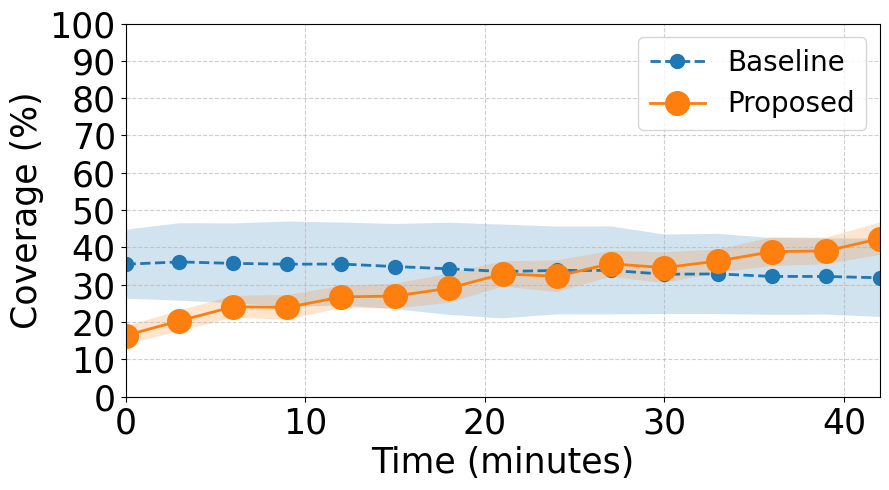

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the csv files
baseline_df = pd.read_csv("45_minutes_data_baseline.csv")
proposed_df = pd.read_csv("45_minutes_data_proposed.csv")

baseline_df["Iteration No"] = baseline_df["Iteration No"] - 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 44]
proposed_df = proposed_df[proposed_df["timestamp"] <= 44]

baseline_stats = baseline_df.groupby("Simulation time")["Coverage"].agg(
    mean="mean",
    std="std"
).reset_index()

proposed_stats = proposed_df.groupby("timestamp")["Coverage"].agg(
    mean="mean",
    std="std"
).reset_index()
# Take data in 3 minutes interval
baseline_stats = baseline_stats[
    (baseline_stats["Simulation time"] <= 44) &
    (baseline_stats["Simulation time"] % 3 == 0)
]
proposed_stats = proposed_stats[
    (proposed_stats["timestamp"] <= 45) &
    (proposed_stats["timestamp"] % 3 == 0)
]
plt.figure(figsize=(9,5))
plt.plot(
    baseline_stats["Simulation time"],
    baseline_stats["mean"],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=10,
    label="Baseline"
)
plt.fill_between(
    baseline_stats["Simulation time"],
    baseline_stats["mean"] - baseline_stats["std"],
    baseline_stats["mean"] + baseline_stats["std"],
    alpha=0.2
)
plt.plot(
    proposed_stats["timestamp"],
    proposed_stats["mean"],
    linestyle="-",
    marker="o",
    linewidth=2,
    markersize=17,
    label="Proposed"
)
plt.fill_between(
    proposed_stats["timestamp"],
    proposed_stats["mean"] - proposed_stats["std"],
    proposed_stats["mean"] + proposed_stats["std"],
    alpha=0.2
)

plt.xlabel("Time (minutes)", fontsize=25)
plt.ylabel("Coverage (%)", fontsize=25)
plt.xlim(0,42)
plt.ylim(bottom=0)
plt.xticks(np.arange(0, 42, 10))
plt.yticks(np.arange(0, 110, 10))
ax = plt.gca()
ax.tick_params(axis='both', labelsize=25)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


#### Fining the insight

In [3]:
import pandas as pd
import numpy as np

# Load csv files

baseline_df = pd.read_csv("45_minutes_data_baseline.csv")
proposed_df = pd.read_csv("45_minutes_data_proposed.csv")


if "Iteration No" in baseline_df.columns:
    baseline_df["Iteration No"] = baseline_df["Iteration No"] - 1


baseline_df = baseline_df[baseline_df["Simulation time"] <= 45]
proposed_df = proposed_df[proposed_df["timestamp"] <= 45]
baseline_mean = baseline_df["Coverage"].mean()
proposed_mean = proposed_df["Coverage"].mean()
absolute_difference = baseline_mean - proposed_mean
percentage_difference = (
    (proposed_mean - baseline_mean) / baseline_mean
) * 100

last_time_baseline = baseline_df["Simulation time"].max()
last_time_proposed = proposed_df["timestamp"].max()


final_baseline = baseline_df[
    baseline_df["Simulation time"] == last_time_baseline
]["Coverage"].mean()

final_proposed = proposed_df[
    proposed_df["timestamp"] == last_time_proposed
]["Coverage"].mean()

final_absolute_diff = final_proposed - final_baseline


print("\n" + "="*60)
print("COVERAGE PERFORMANCE COMPARISON (45 MINUTES)")
print("="*60)
print(f"\nBaseline Average Coverage  : {baseline_mean:.2f}%")
print(f"Proposed Average Coverage  : {proposed_mean:.2f}%")
print(f"\nAbsolute Difference (Baseline - Proposed): {absolute_difference:.2f} percentage points")
print(f"Relative Percentage Difference: {percentage_difference:.2f}%")
print("\n----- Final Time Comparison -----")
print(f"Final Time (Baseline): {last_time_baseline} minutes")
print(f"Final Time (Proposed): {last_time_proposed} minutes")
print(f"Final Baseline Coverage : {final_baseline:.2f}%")
print(f"Final Proposed Coverage : {final_proposed:.2f}%")
print(f"Final Absolute Difference (Proposed - Baseline): {final_absolute_diff:.2f} percentage points")
print("\n" + "="*60 + "\n")



COVERAGE PERFORMANCE COMPARISON (45 MINUTES)

Baseline Average Coverage  : 33.93%
Proposed Average Coverage  : 31.51%

Absolute Difference (Baseline - Proposed): 2.42 percentage points
Relative Percentage Difference: -7.14%

----- Final Time Comparison -----
Final Time (Baseline): 45 minutes
Final Time (Proposed): 45 minutes
Final Baseline Coverage : 32.08%
Final Proposed Coverage : 41.51%
Final Absolute Difference (Proposed - Baseline): 9.43 percentage points




## Network Efficiency

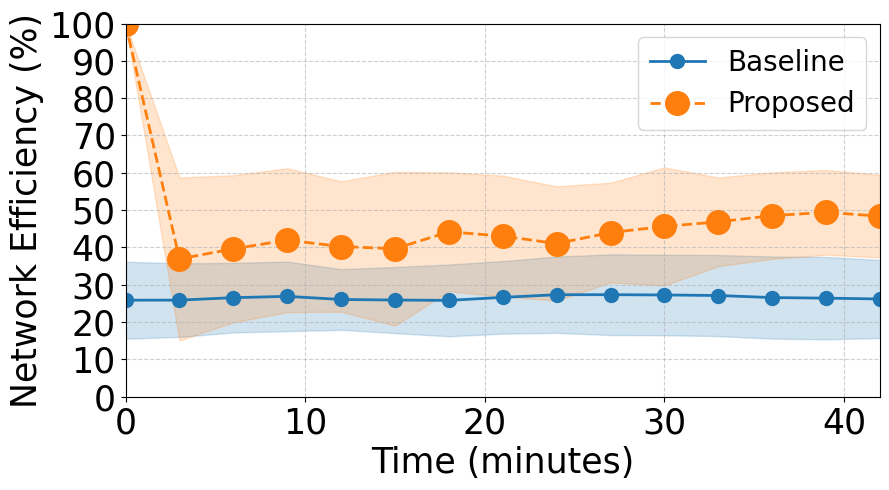

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Load CSV files
baseline_df = pd.read_csv("45_minutes_data_baseline.csv")
proposed_df = pd.read_csv("45_minutes_data_proposed.csv")

baseline_df["Iteration No"] = baseline_df["Iteration No"] - 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 44]
proposed_df = proposed_df[proposed_df["timestamp"] <= 44]
baseline_stats = (
    baseline_df
    .groupby("Simulation time")["Network efficiency"]
    .agg(mean="mean", std="std")
    .reset_index()
)

proposed_stats = (
    proposed_df
    .groupby("timestamp")["network_efficiency"]
    .agg(mean="mean", std="std")
    .reset_index()
)
baseline_stats = baseline_stats[
    (baseline_stats["Simulation time"] <= 44) &
    (baseline_stats["Simulation time"] % 3 == 0)
]

proposed_stats = proposed_stats[
    (proposed_stats["timestamp"] <= 45) &
    (proposed_stats["timestamp"] % 3 == 0)
]

baseline_stats[["mean", "std"]] *= 100
proposed_stats[["mean", "std"]] *= 100
plt.figure(figsize=(9, 5))
plt.plot(
    baseline_stats["Simulation time"],
    baseline_stats["mean"],
    linestyle="-",
    marker="o",
    linewidth=2,
    color="#1f77b4",
    markersize=10,
    label="Baseline"
)
plt.fill_between(
    baseline_stats["Simulation time"],
    baseline_stats["mean"] - baseline_stats["std"],
    baseline_stats["mean"] + baseline_stats["std"],
    alpha=0.2,
    color="#1f77b4"
)
plt.plot(
    proposed_stats["timestamp"],
    proposed_stats["mean"],
    linestyle="--",
    marker="o",
    linewidth=2,
    color="#ff7f0e",
    markersize=17,
    label="Proposed"
)
plt.fill_between(
    proposed_stats["timestamp"],
    proposed_stats["mean"] - proposed_stats["std"],
    proposed_stats["mean"] + proposed_stats["std"],
    alpha=0.2,
    color="#ff7f0e"
)
plt.xlabel("Time (minutes)", fontsize=25)
plt.ylabel("Network Efficiency (%)", fontsize=25)
plt.xlim(0,42)
plt.ylim(0, 70)
plt.xticks(np.arange(0, 42, 10))
plt.yticks(np.arange(0, 110, 10))
ax = plt.gca()
ax.tick_params(axis="both", labelsize=25)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


## No of connected components

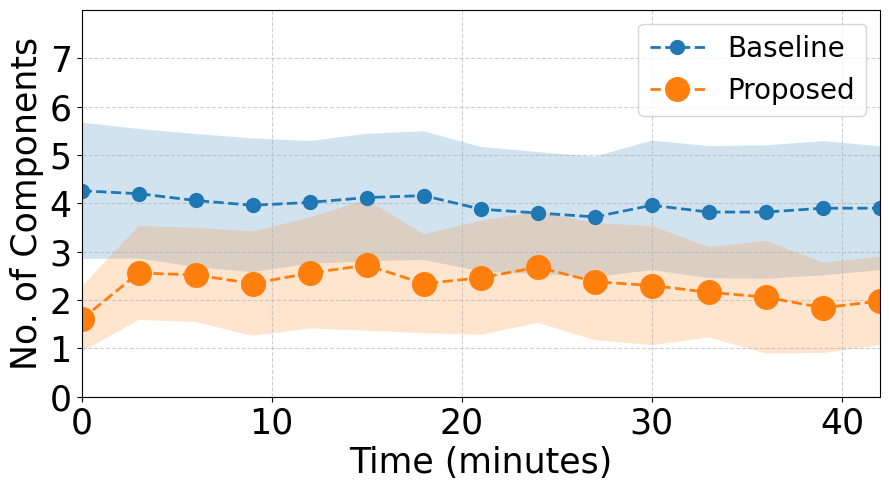

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV files
baseline_df = pd.read_csv("45_minutes_data_baseline.csv")
proposed_df = pd.read_csv("45_minutes_data_proposed.csv")

baseline_df["Iteration No"] = baseline_df["Iteration No"] - 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 44]
proposed_df = proposed_df[proposed_df["timestamp"] <= 44]

baseline_stats = baseline_df.groupby("Simulation time")["No of connected components"].agg(
    mean="mean",
    std="std"
).reset_index()
proposed_stats = proposed_df.groupby("timestamp")["num_components"].agg(
    mean="mean",
    std="std"
).reset_index()

baseline_stats = baseline_stats[
    baseline_stats["Simulation time"].round() % 3 == 0
]
proposed_stats = proposed_stats[
    proposed_stats["timestamp"].round() % 3 == 0
]

plt.figure(figsize=(9,5))
plt.plot(
    baseline_stats["Simulation time"],
    baseline_stats["mean"],
    linestyle="--",
    marker="o",
    markersize=10,
    linewidth=2,
    label="Baseline"
)
plt.fill_between(
    baseline_stats["Simulation time"],
    baseline_stats["mean"] - baseline_stats["std"],
    baseline_stats["mean"] + baseline_stats["std"],
    alpha=0.2
)
plt.plot(
    proposed_stats["timestamp"],
    proposed_stats["mean"],
    linestyle="--",
    marker="o",
    markersize=17,
    linewidth=2,
    label="Proposed"
)
plt.fill_between(
    proposed_stats["timestamp"],
    proposed_stats["mean"] - proposed_stats["std"],
    proposed_stats["mean"] + proposed_stats["std"],
    alpha=0.2
)

plt.xlabel("Time (minutes)", fontsize=25)
plt.ylabel("No. of Components", fontsize=25)
plt.xlim(0,42)
plt.ylim(0, 8)
plt.xticks(np.arange(0, 42, 10))
plt.yticks(np.arange(0, 8, 1))
ax = plt.gca()
ax.tick_params(axis='both', labelsize=25)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=20, loc="upper right")
plt.tight_layout()
plt.show()


#### Fining the insight

###### No of connected components

In [ ]:
import pandas as pd


# Load CSV files
baseline_df = pd.read_csv("45_minutes_data_baseline.csv")
proposed_df = pd.read_csv("45_minutes_data_proposed.csv")
baseline_df["Iteration No"] -= 1

baseline_df = baseline_df[baseline_df["Simulation time"] <= 75]
proposed_df = proposed_df[proposed_df["timestamp"] <= 75]

baseline_mean = (
    baseline_df
    .groupby("Simulation time")["No of connected components"]
    .mean()
    .reset_index(name="baseline_mean")
)

proposed_mean = (
    proposed_df
    .groupby("timestamp")["num_components"]
    .mean()
    .reset_index(name="proposed_mean")
)
merged = pd.merge(
    baseline_mean,
    proposed_mean,
    left_on="Simulation time",
    right_on="timestamp"
)

avg_reduction = (
    merged["baseline_mean"] - merged["proposed_mean"]
).mean()

print(f"Average reduction in connected components: {avg_reduction:.2f}")


Average reduction in connected components: 1.62


###### Network Efficiency

In [8]:
import pandas as pd


# Load CSV files
baseline_df = pd.read_csv("45_minutes_data_baseline.csv")
proposed_df = pd.read_csv("45_minutes_data_proposed.csv")


baseline_df["Iteration No"] -= 1
baseline_df = baseline_df[baseline_df["Simulation time"] <= 75]
proposed_df = proposed_df[proposed_df["timestamp"] <= 75]

baseline_mean = (
    baseline_df
    .groupby("Simulation time")["Network efficiency"]
    .mean()
    .reset_index(name="NE_baseline")
)

proposed_mean = (
    proposed_df
    .groupby("timestamp")["network_efficiency"]
    .mean()
    .reset_index(name="NE_proposed")
)

merged = pd.merge(
    baseline_mean,
    proposed_mean,
    left_on="Simulation time",
    right_on="timestamp"
)

avg_gain_pp = (
    merged["NE_proposed"] - merged["NE_baseline"]
).mean() * 100   # multiply by 100 to convert to percentage
print(
    f"Average network efficiency improvement: "
    f"{avg_gain_pp:.2f} percentage points"
)


Average network efficiency improvement: 17.62 percentage points
